Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load Dataset

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Data Cleaning

In [5]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Check for Duplicate Rows

In [7]:
# Total duplicate rows
df.duplicated().sum()

np.int64(0)

Exploratory Data Analysis (EDA)

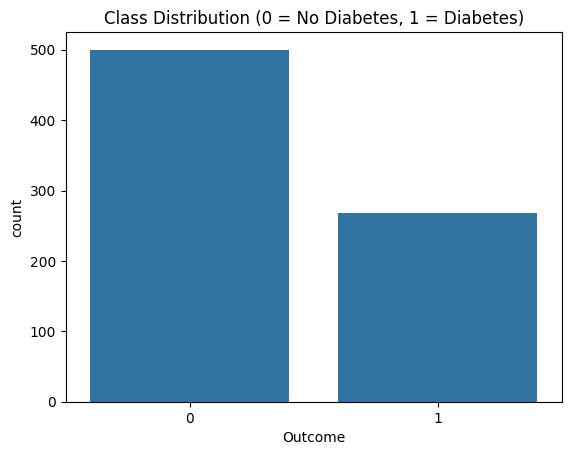

In [8]:
sns.countplot(x='Outcome', data=df)
plt.title("Class Distribution (0 = No Diabetes, 1 = Diabetes)")
plt.show()

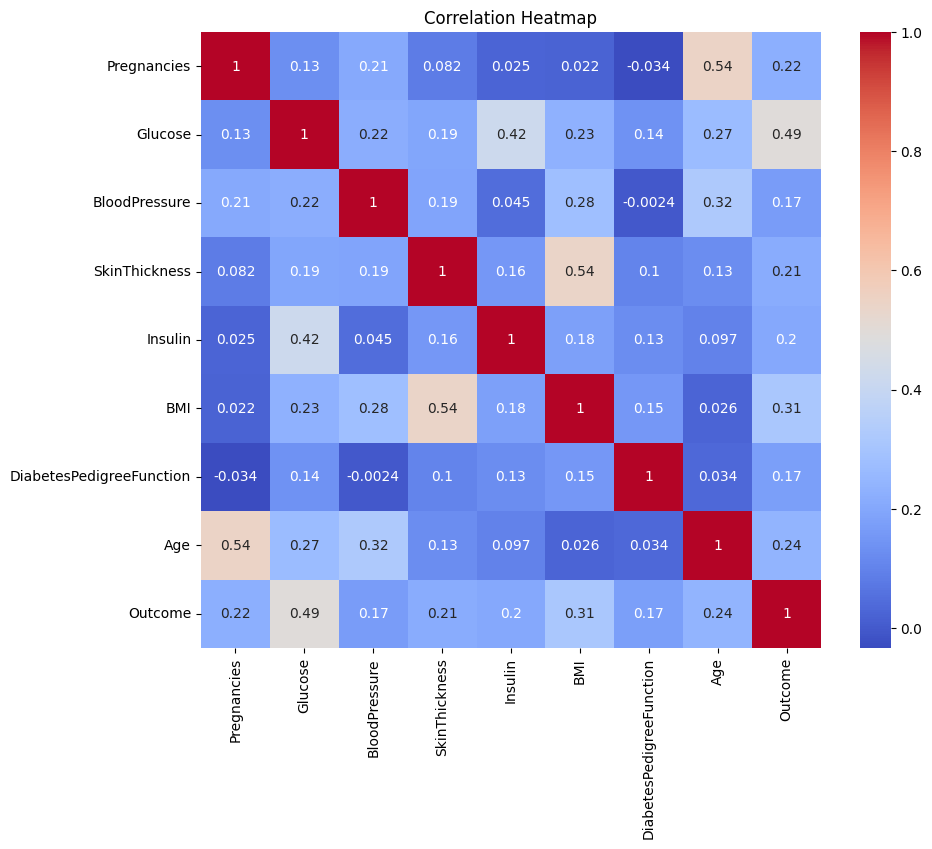

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

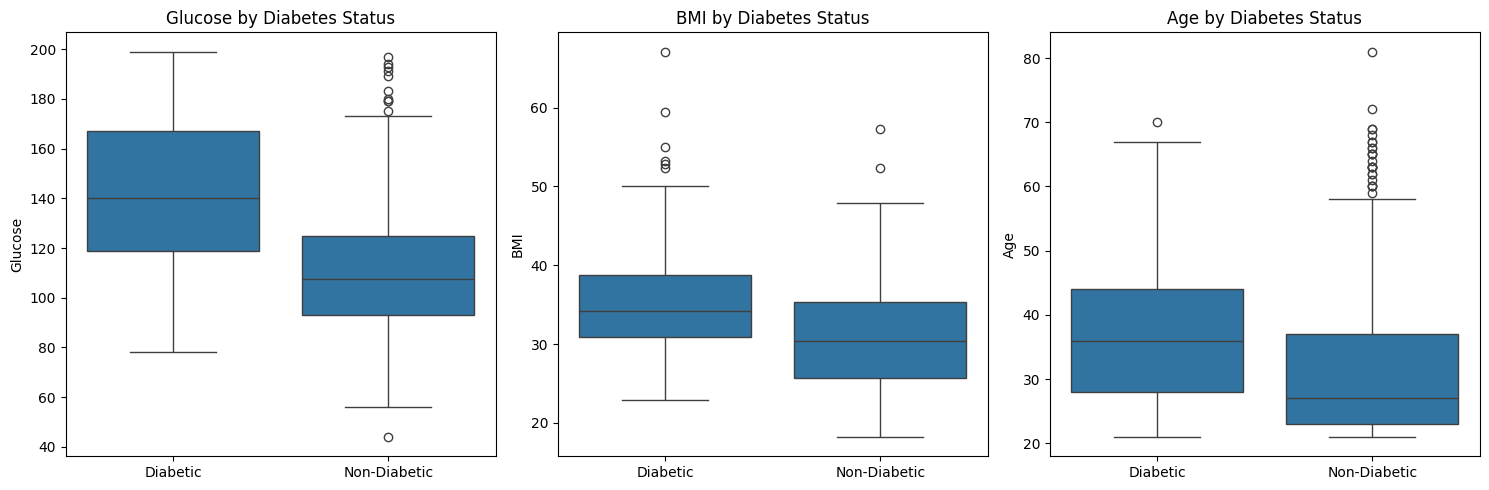

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Make labels more readable
df['Outcome_Label'] = df['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

# Create figure
plt.figure(figsize=(15,5))

# Plot 1: Glucose
plt.subplot(1,3,1)
sns.boxplot(x='Outcome_Label', y='Glucose', data=df)
plt.title("Glucose by Diabetes Status")
plt.xlabel("")
plt.ylabel("Glucose")

# Plot 2: BMI
plt.subplot(1,3,2)
sns.boxplot(x='Outcome_Label', y='BMI', data=df)
plt.title("BMI by Diabetes Status")
plt.xlabel("")
plt.ylabel("BMI")

# Plot 3: Age
plt.subplot(1,3,3)
sns.boxplot(x='Outcome_Label', y='Age', data=df)
plt.title("Age by Diabetes Status")
plt.xlabel("")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

In [11]:
df.drop("Outcome_Label", axis=1, inplace=True)

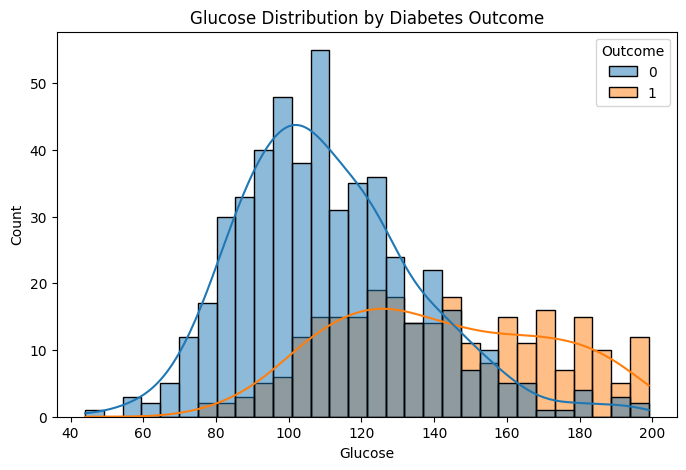

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Glucose", hue="Outcome", kde=True, bins=30)
plt.title("Glucose Distribution by Diabetes Outcome")
plt.show()

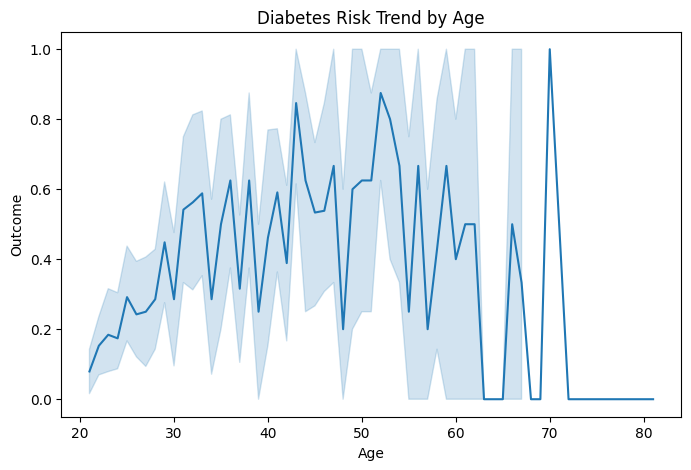

In [13]:
plt.figure(figsize=(8,5))
sns.lineplot(x="Age", y="Outcome", data=df)
plt.title("Diabetes Risk Trend by Age")
plt.show()

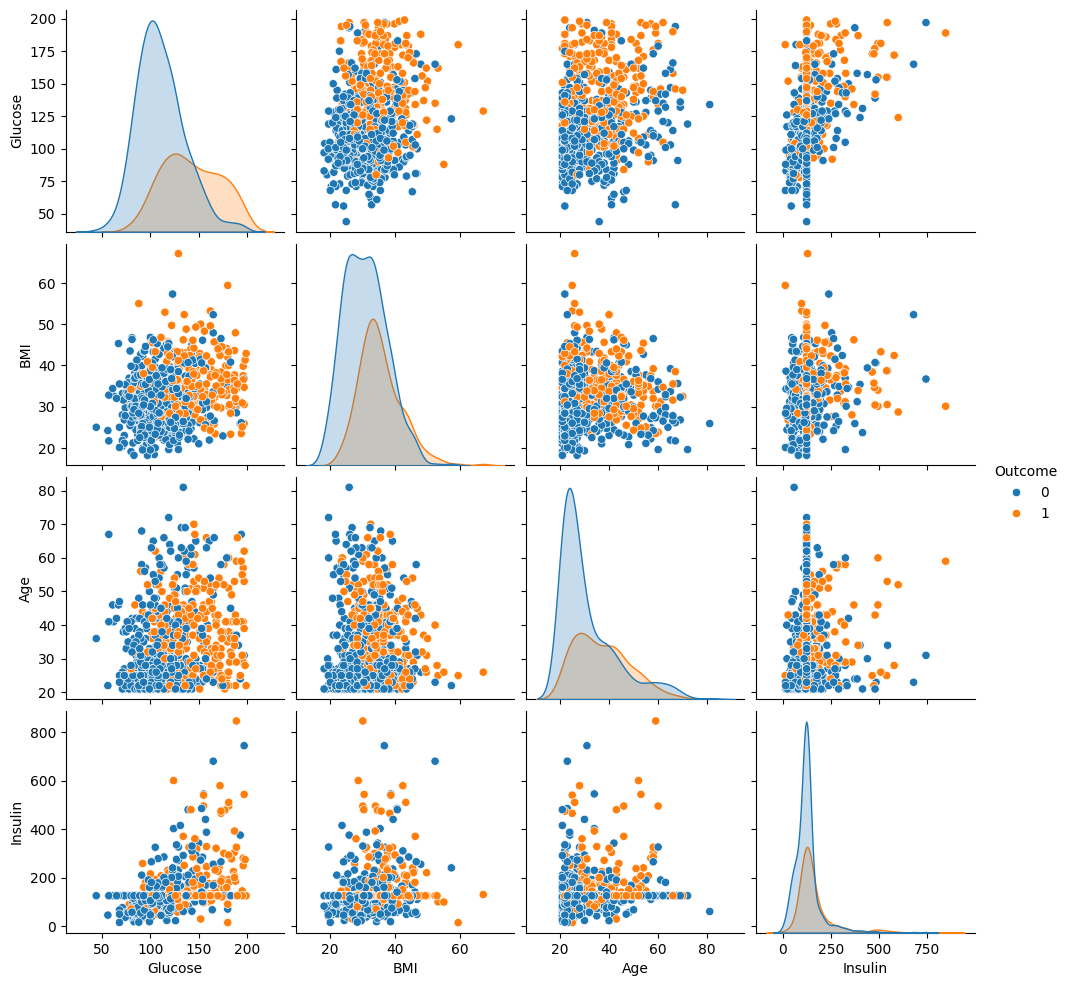

In [14]:
sns.pairplot(df, hue="Outcome", vars=["Glucose", "BMI", "Age", "Insulin"])
plt.show()

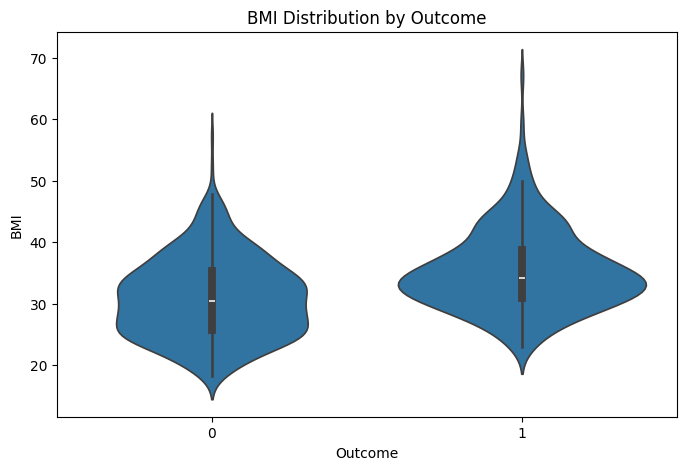

In [15]:
plt.figure(figsize=(8,5))
sns.violinplot(x="Outcome", y="BMI", data=df)
plt.title("BMI Distribution by Outcome")
plt.show()

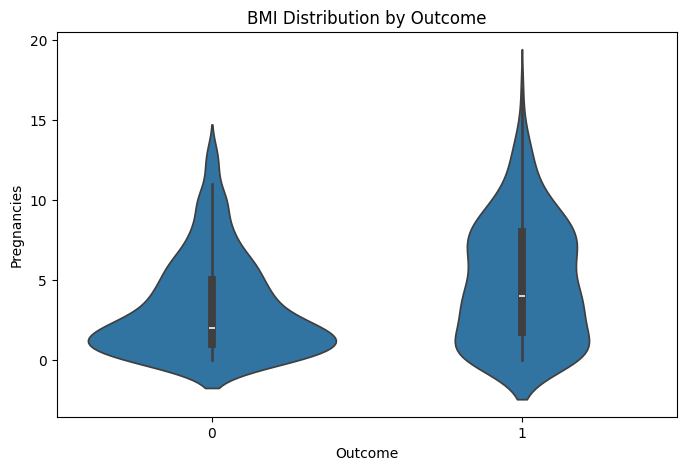

In [16]:
plt.figure(figsize=(8,5))
sns.violinplot(x="Outcome", y="Pregnancies", data=df)
plt.title("BMI Distribution by Outcome")
plt.show()

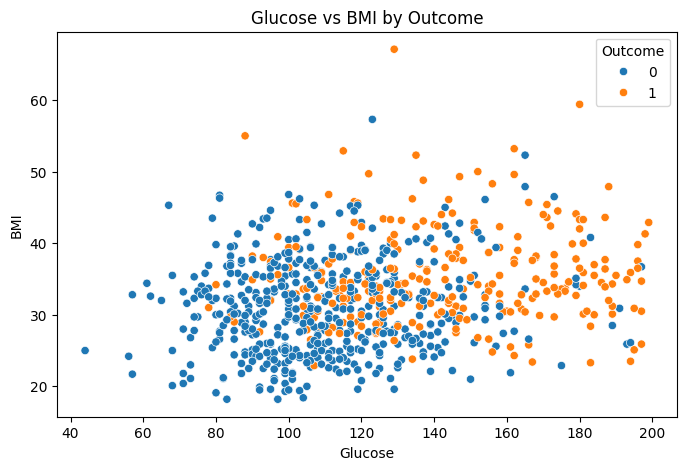

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Glucose", y="BMI", hue="Outcome")
plt.title("Glucose vs BMI by Outcome")
plt.show()

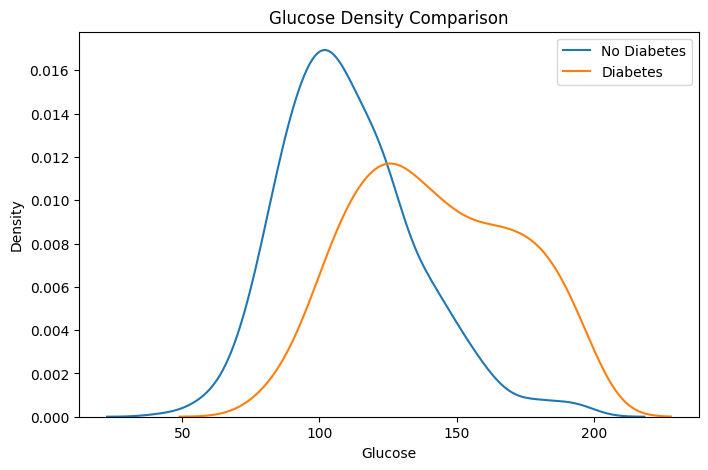

In [18]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df[df["Outcome"]==0]["Glucose"], label="No Diabetes")
sns.kdeplot(data=df[df["Outcome"]==1]["Glucose"], label="Diabetes")
plt.legend()
plt.title("Glucose Density Comparison")
plt.show()

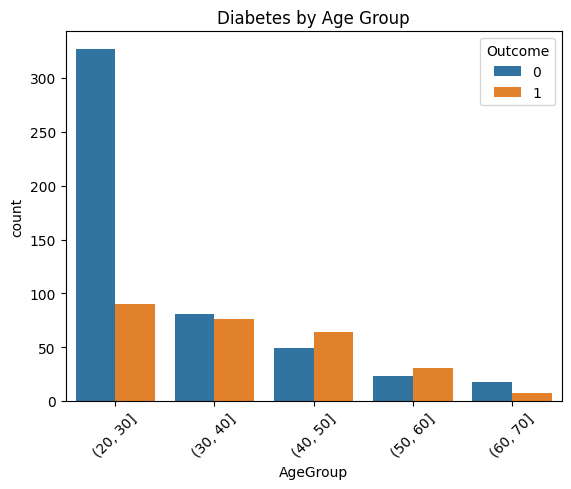

In [19]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[20,30,40,50,60,70])
sns.countplot(x="AgeGroup", hue="Outcome", data=df)
plt.xticks(rotation=45)
plt.title("Diabetes by Age Group")
plt.show()

Prepare Data for Modeling

In [20]:
df = df.drop("AgeGroup", axis=1)

In [21]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression

In [24]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

Model Evaluation

In [25]:
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7662337662337663

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.86      0.83        99
           1       0.70      0.60      0.65        55

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



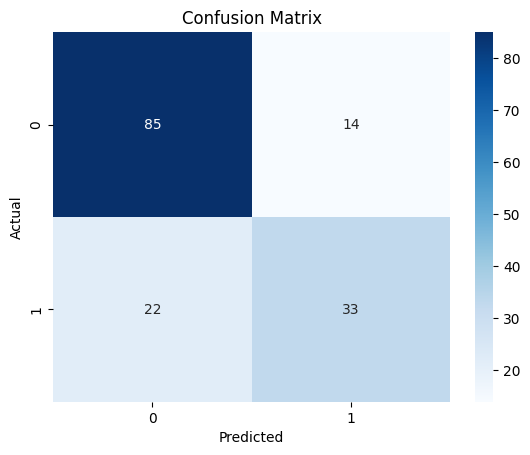

In [26]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature Importance (Logistic Coefficients)

In [27]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
1,Glucose,4.127761
5,BMI,2.740556
7,Age,1.523918
6,DiabetesPedigreeFunction,0.998927
0,Pregnancies,0.972041
3,SkinThickness,0.851707
4,Insulin,-0.013767
2,BloodPressure,-0.131041


Decision Tree

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7207792207792207

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78        99
           1       0.60      0.64      0.62        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



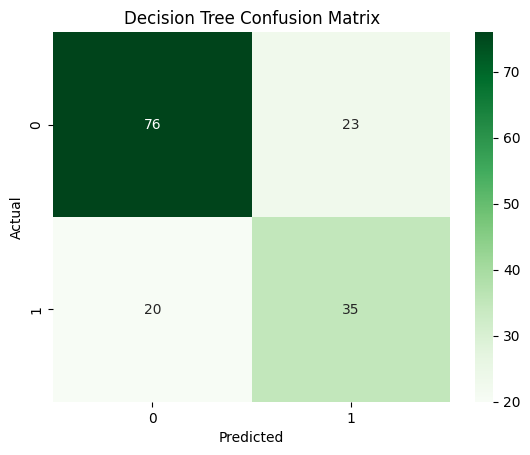

In [29]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [30]:
feature_importance_dt = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_dt

,Feature,Importance
1,Glucose,0.357487
5,BMI,0.164377
7,Age,0.131524
6,DiabetesPedigreeFunction,0.115416
4,Insulin,0.087381
2,BloodPressure,0.079928
3,SkinThickness,0.035927
0,Pregnancies,0.027960


Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7467532467532467

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



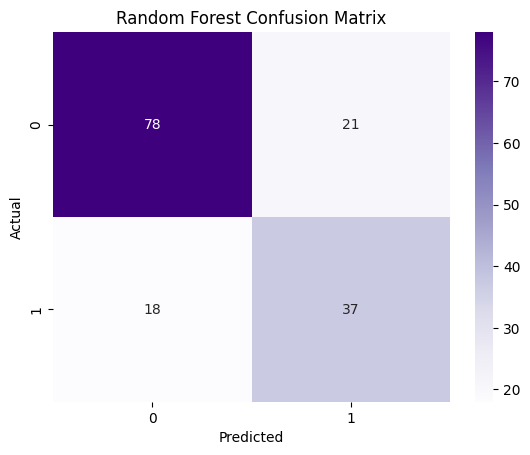

In [32]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [33]:
feature_importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_rf

,Feature,Importance
1,Glucose,0.263453
5,BMI,0.164118
7,Age,0.134927
6,DiabetesPedigreeFunction,0.121819
4,Insulin,0.089248
2,BloodPressure,0.084062
3,SkinThickness,0.072432
0,Pregnancies,0.069942


Support Vector Machine (SVM)

In [34]:
from sklearn.svm import SVC

# Initialize model
svm_model = SVC(kernel='rbf', random_state=42)

# Train
svm_model.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7532467532467533

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.82        99
           1       0.69      0.56      0.62        55

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



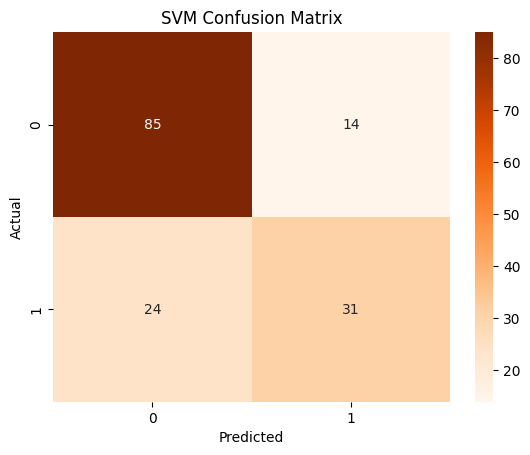

In [35]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

Model Comparison Table

In [36]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Create comparison dictionary
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision (Diabetes=1)": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm)
    ],
    "Recall (Diabetes=1)": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm)
    ],
    "F1-Score (Diabetes=1)": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm)
    ]
})

comparison

,Model,Accuracy,Precision (Diabetes=1),Recall (Diabetes=1),F1-Score (Diabetes=1)
0,Logistic Regression,0.766234,0.702128,0.600000,0.647059
1,Decision Tree,0.720779,0.603448,0.636364,0.619469
2,Random Forest,0.746753,0.637931,0.672727,0.654867
3,SVM,0.753247,0.688889,0.563636,0.620000


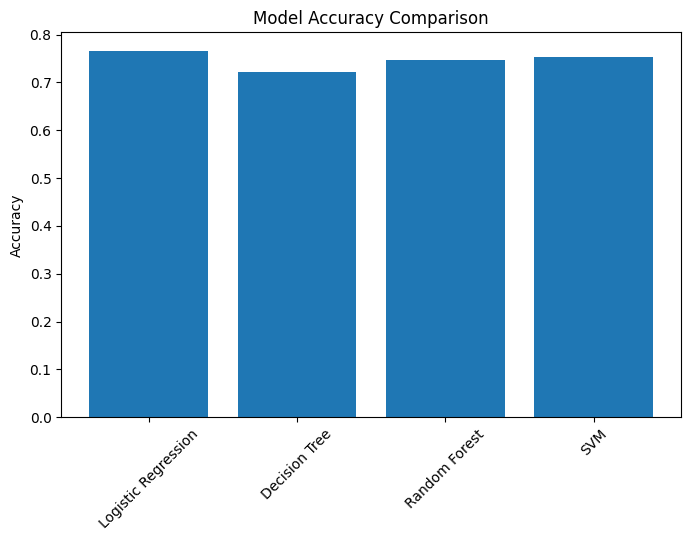

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()